<div style="background: linear-gradient(135deg,#0f2027,#203a43,#2c5364); padding:30px; border-radius:15px; color:white; font-family:Arial;">

<h1 style="text-align:center; color:#00E5FF;"> Smart Surveillance RAG</h1>

<h3 style="text-align:center; color:#FFD54F;">
Retrieval-Augmented Generation for Intelligent Video Querying
</h3>

<hr style="border:1px solid #00E5FF;">

<h2 style="color:#4FC3F7;"> Project Overview</h2>

<p style="font-size:16px; line-height:1.6;">
<strong>Smart Surveillance RAG</strong> is an intelligent video analysis system designed to enable 
<strong>natural language querying of surveillance footage</strong>. By combining 
<strong>computer vision, dense vector retrieval, and large language models</strong>, 
the system processes raw video, extracts semantic information, and answers user questions with 
relevant frames and generated text.
</p>

<p style="font-size:16px;">
It transforms traditional video monitoring into an <strong>interactive, searchable experience</strong>.
</p>

<hr>

<h2 style="color:#4FC3F7;"> Methodology</h2>

<div style="background:#1e293b; padding:20px; border-radius:10px;">

<ol style="line-height:1.8; font-size:15px;">

<li><strong style="color:#FFD54F;">Video Sampling</strong><br>
Frames are extracted at a defined rate (e.g., <strong>1 FPS</strong>) to reduce redundancy.
</li>

<li><strong style="color:#FFD54F;">Object Detection</strong><br>
A <strong>YOLOv8</strong> model detects objects in each frame (person, car, etc.).
</li>

<li><strong style="color:#FFD54F;">Description Generation</strong><br>
Detections are converted into timestamped natural language descriptions.
</li>

<li><strong style="color:#FFD54F;">Vector Indexing</strong><br>
Descriptions are embedded using <strong>SentenceTransformer</strong> and indexed with <strong>FAISS</strong>.
</li>

<li><strong style="color:#FFD54F;">Query & Answering</strong><br>
User queries retrieve the most relevant frame descriptions, and 
<strong>Flan-T5</strong> generates concise answers.
</li>

</ol>

</div>

<hr>

<h2 style="color:#4FC3F7;"> Key Features</h2>

<ul style="font-size:15px; line-height:1.8;">

<li> <strong>Natural Language Interaction</strong> – Ask questions like 
<i>"How many people are visible?"</i> or 
<i>"Were there vehicles at the beginning?"</i>.
</li>

<li> <strong>Frame-Level Retrieval</strong> – Returns the most relevant frames with similarity scores.</li>

<li> <strong>Context-Aware Generation</strong> – Combines retrieved descriptions into a coherent answer.</li>

<li> <strong>Scalable & Modular</strong> – Detection, retrieval, and generation components can be upgraded independently.</li>

<li> <strong>Optimized for Kaggle</strong> – Runs efficiently using Kaggle’s free GPU/TPU.</li>

</ul>

<hr>

<h2 style="color:#4FC3F7;"> Technologies Used</h2>

<div style="background:#1e293b; padding:20px; border-radius:10px;">

<ul style="line-height:1.8; font-size:15px;">

<li> <strong>Python</strong> – Core programming language</li>
<li> <strong>YOLOv8 (Ultralytics)</strong> – Real-time object detection</li>
<li> <strong>SentenceTransformers</strong> – Text embedding generation</li>
<li> <strong>FAISS</strong> – Fast similarity search</li>
<li> <strong>Transformers (Flan-T5)</strong> – Answer generation</li>
<li> <strong>OpenCV</strong> – Video processing</li>
<li> <strong>Matplotlib & Pandas</strong> – Visualization and analysis</li>

</ul>

</div>

<hr>

<h2 style="color:#4FC3F7;"> Results & Analysis</h2>

<p style="font-size:16px; line-height:1.6;">
The system successfully retrieves relevant frames for various 
<strong>temporal</strong> and <strong>object-centric</strong> queries.
</p>

<p>
Example queries include:
</p>

<ul>
<li>"Are there people walking?"</li>
<li>"What objects are present at 2 seconds?"</li>
</ul>

<p>
The generated answers provide concise summaries such as:
</p>

<p style="background:#263238; padding:12px; border-radius:8px; color:#B2FF59;">
"Multiple people are walking in the scene."
</p>

<hr>

<h2 style="color:#4FC3F7;">🌍 Potential Applications</h2>

<ul style="line-height:1.8; font-size:15px;">

<li> <strong>Security & Surveillance</strong> – Search hours of footage instantly.</li>
<li> <strong>Smart Homes</strong> – Ask about daily activities captured by cameras.</li>
<li> <strong>Retail Analytics</strong> – Monitor customer movement and interactions.</li>
<li> <strong>Academic Research</strong> – Prototype for video question answering.</li>

</ul>

<hr>

<h2 style="color:#4FC3F7;">🏁 Conclusion</h2>

<p style="font-size:16px; line-height:1.6;">
<strong>Smart Surveillance RAG</strong> demonstrates how modern AI techniques can transform video data 
into a <strong>searchable and interactive knowledge source</strong> using natural language.
</p>

<p>
Its modular architecture allows easy integration of advanced models for future improvements in 
<strong>video understanding and multimodal retrieval</strong>.
</p>

</div>

<h2 style="
text-align:center;
color:#203a43;
font-weight:bold;
font-size:34px;
letter-spacing:1px;
text-shadow: 2px 2px 6px rgba(32,58,67,0.35);
margin-top:20px;
">
Environment Setup & Installations</h2>

In [1]:
!pip install -q ultralytics
!pip install -q sentence-transformers
!pip install -q faiss-cpu          # Use CPU version; GPU version unavailable on Kaggle
!pip install -q transformers
!pip install -q opencv-python-headless
!pip install -q matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 20.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 72.6 MB/s eta 0:00:00


<h2 style="
text-align:center;
color:#203a43;
font-weight:bold;
font-size:34px;
letter-spacing:1px;
text-shadow: 2px 2px 6px rgba(32,58,67,0.35);
margin-top:20px;
">
 Import Libraries
</h2>

In [2]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.notebook import tqdm
import warnings
warnings.filterwarnings('ignore')

from ultralytics import YOLO

from sentence_transformers import SentenceTransformer

import faiss

from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

from google.colab.patches import cv2_imshow  

print("All libraries imported successfully.")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
All libraries imported successfully.


<h2 style="
text-align:center;
color:#203a43;
font-weight:bold;
font-size:34px;
letter-spacing:1px;
text-shadow: 2px 2px 6px rgba(32,58,67,0.35);
margin-top:20px;
">
Load and Explore Data</h2>

In [3]:
!wget -O sample_video.mp4 https://github.com/intel-iot-devkit/sample-videos/raw/master/face-demographics-walking-and-pause.mp4

VIDEO_PATH = "sample_video.mp4"
print(f"Video downloaded: {VIDEO_PATH}")

cap = cv2.VideoCapture(VIDEO_PATH)
fps = int(cap.get(cv2.CAP_PROP_FPS))
frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
duration = frame_count / fps
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
cap.release()

print(f"FPS: {fps}")
print(f"Total frames: {frame_count}")
print(f"Duration: {duration:.2f} seconds")
print(f"Resolution: {width} x {height}")

--2026-03-08 11:35:59--  https://github.com/intel-iot-devkit/sample-videos/raw/master/face-demographics-walking-and-pause.mp4
Resolving github.com (github.com)... 140.82.112.4
Connecting to github.com (github.com)|140.82.112.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/intel-iot-devkit/sample-videos/master/face-demographics-walking-and-pause.mp4 [following]
--2026-03-08 11:36:00--  https://raw.githubusercontent.com/intel-iot-devkit/sample-videos/master/face-demographics-walking-and-pause.mp4
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.111.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 9406029 (9.0M) [application/octet-stream]
Saving to: ‘sample_video.mp4’

sample_video.mp4    100%[===================>]   8.97M  --.-KB/s    in 0.1s    


<h2 style="
text-align:center;
color:#203a43;
font-weight:bold;
font-size:30px;
letter-spacing:1px;
text-shadow: 2px 2px 6px rgba(32,58,67,0.35);
margin-top:20px;
">
Frame Extraction and Preprocessing</h2>

In [4]:
SAMPLE_RATE = 1  
output_frames_dir = "extracted_frames"
os.makedirs(output_frames_dir, exist_ok=True)

def extract_frames(video_path, sample_rate):
    cap = cv2.VideoCapture(video_path)
    fps = int(cap.get(cv2.CAP_PROP_FPS))
    frame_interval = fps // sample_rate   
    frames_info = []   

    frame_id = 0
    saved_count = 0

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        if frame_id % frame_interval == 0:
            timestamp = frame_id / fps
            img_path = os.path.join(output_frames_dir, f"frame_{saved_count:04d}.jpg")
            cv2.imwrite(img_path, frame)
            frames_info.append((saved_count, timestamp, img_path))
            saved_count += 1

        frame_id += 1

    cap.release()
    print(f"Extracted {saved_count} frames.")
    return frames_info

frames_info = extract_frames(VIDEO_PATH, SAMPLE_RATE)

# Convert to DataFrame for easy analysis
df_frames = pd.DataFrame(frames_info, columns=["frame_idx", "timestamp", "image_path"])
df_frames.head()

Extracted 91 frames.


,frame_idx,timestamp,image_path
0,0,0.0,extracted_frames/frame_0000.jpg
1,1,1.0,extracted_frames/frame_0001.jpg
2,2,2.0,extracted_frames/frame_0002.jpg
3,3,3.0,extracted_frames/frame_0003.jpg
4,4,4.0,extracted_frames/frame_0004.jpg


<h2 style="
text-align:center;
color:#203a43;
font-weight:bold;
font-size:34px;
letter-spacing:1px;
text-shadow: 2px 2px 6px rgba(32,58,67,0.35);
margin-top:20px;
">
Object Detection with YOLOv8</h2>

In [5]:
yolo_model = YOLO('yolov8n.pt')  

def detect_objects(image_path):
    results = yolo_model(image_path, verbose=False)  
    detections = results[0].boxes
    if detections is None:
        return []
    class_ids = detections.cls.cpu().numpy().astype(int)
    class_names = [yolo_model.names[cid] for cid in class_ids]
    return class_names

descriptions = []

for idx, row in tqdm(df_frames.iterrows(), total=len(df_frames), desc="Detecting objects"):
    img_path = row["image_path"]
    timestamp = row["timestamp"]
    objects = detect_objects(img_path)

    if objects:
        obj_counts = pd.Series(objects).value_counts().to_dict()
        obj_str = ", ".join([f"{cnt} {obj}" + ("s" if cnt>1 else "") for obj, cnt in obj_counts.items()])
        desc = f"At {timestamp:.2f} seconds: {obj_str}."
    else:
        desc = f"At {timestamp:.2f} seconds: no objects detected."

    descriptions.append({
        "frame_idx": row["frame_idx"],
        "timestamp": timestamp,
        "image_path": img_path,
        "objects": objects,
        "description": desc
    })

df_descriptions = pd.DataFrame(descriptions)
print(df_descriptions[["timestamp", "description"]].head(10))

Detecting objects:   0%|          | 0/91 [00:00<?, ?it/s]

   timestamp                            description
0        0.0  At 0.00 seconds: no objects detected.
1        1.0  At 1.00 seconds: no objects detected.
2        2.0  At 2.00 seconds: no objects detected.
3        3.0  At 3.00 seconds: no objects detected.
4        4.0             At 4.00 seconds: 1 person.
5        5.0             At 5.00 seconds: 1 person.
6        6.0             At 6.00 seconds: 1 person.
7        7.0             At 7.00 seconds: 1 person.
8        8.0             At 8.00 seconds: 1 person.
9        9.0             At 9.00 seconds: 1 person.


<h2 style="
text-align:center;
color:#203a43;
font-weight:bold;
font-size:34px;
letter-spacing:1px;
text-shadow: 2px 2px 6px rgba(32,58,67,0.35);
margin-top:20px;
">
Analyze the Detected Objects Across</h2>

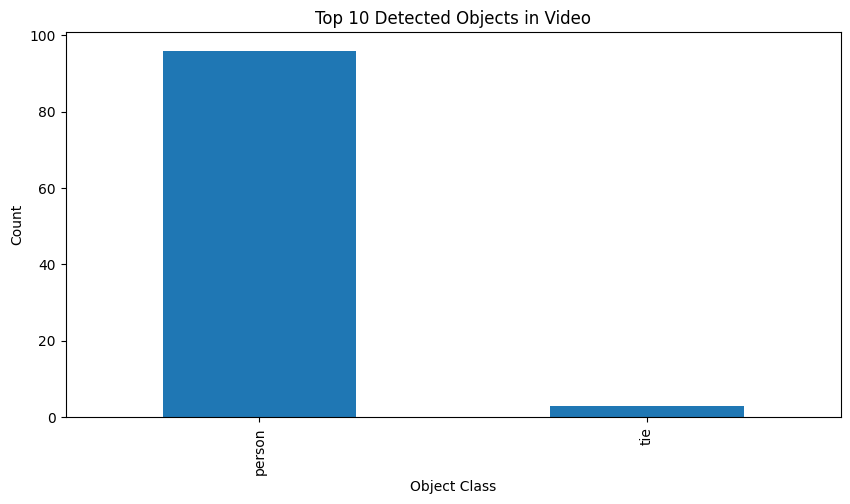

Total detections: 99
Unique object types: 2


In [6]:
all_objects = []
for obj_list in df_descriptions["objects"]:
    all_objects.extend(obj_list)

object_series = pd.Series(all_objects)
object_counts = object_series.value_counts()

plt.figure(figsize=(10,5))
object_counts.head(10).plot(kind='bar')
plt.title("Top 10 Detected Objects in Video")
plt.xlabel("Object Class")
plt.ylabel("Count")
plt.show()

print(f"Total detections: {len(all_objects)}")
print(f"Unique object types: {object_series.nunique()}")

<h2 style="
text-align:center;
color:#203a43;
font-weight:bold;
font-size:30px;
letter-spacing:1px;
text-shadow: 2px 2px 6px rgba(32,58,67,0.35);
margin-top:20px;
">
Generate Embeddings for Descriptions</h2>

In [7]:
embedder = SentenceTransformer('all-MiniLM-L6-v2')  

descriptions_list = df_descriptions["description"].tolist()
print(f"Generating embeddings for {len(descriptions_list)} descriptions...")
embeddings = embedder.encode(descriptions_list, show_progress_bar=True, convert_to_numpy=True)
print(f"Embedding shape: {embeddings.shape}")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Generating embeddings for 91 descriptions...


Batches:   0%|          | 0/3 [00:00<?, ?it/s]

Embedding shape: (91, 384)


<h2 style="
text-align:center;
color:#203a43;
font-weight:bold;
font-size:34px;
letter-spacing:1px;
text-shadow: 2px 2px 6px rgba(32,58,67,0.35);
margin-top:20px;
">
Build FAISS Index</h2>

In [8]:
faiss.normalize_L2(embeddings)

dimension = embeddings.shape[1]
index = faiss.IndexFlatIP(dimension)   
index.add(embeddings)
print(f"FAISS index contains {index.ntotal} vectors.")

FAISS index contains 91 vectors.


<h2 style="
text-align:center;
color:#203a43;
font-weight:bold;
font-size:34px;
letter-spacing:1px;
text-shadow: 2px 2px 6px rgba(32,58,67,0.35);
margin-top:20px;
">
 Save index and metadata
</h2>

In [9]:
faiss.write_index(index, "surveillance_index.faiss")
df_descriptions.to_csv("frame_metadata.csv", index=False)
print("Index and metadata saved.")

Index and metadata saved.


<h2 style="
text-align:center;
color:#203a43;
font-weight:bold;
font-size:34px;
letter-spacing:1px;
text-shadow: 2px 2px 6px rgba(32,58,67,0.35);
margin-top:20px;
">
Query and Retrieve</h2>

In [10]:
def retrieve_frames(query, k=3):
    query_emb = embedder.encode([query], convert_to_numpy=True)
    faiss.normalize_L2(query_emb)

    scores, indices = index.search(query_emb, k)
    results = []
    for score, idx in zip(scores[0], indices[0]):
        if idx != -1:
            row = df_descriptions.iloc[idx]
            results.append({
                "frame_idx": row["frame_idx"],
                "timestamp": row["timestamp"],
                "description": row["description"],
                "score": float(score),
                "image_path": row["image_path"]
            })
    return results

query = "Are there any people walking?"
retrieved = retrieve_frames(query, k=3)
print(f"Query: {query}\n")
for i, res in enumerate(retrieved):
    print(f"Result {i+1}: [Score={res['score']:.3f}] {res['description']}")

Query: Are there any people walking?

Result 1: [Score=0.360] At 66.00 seconds: 3 persons.
Result 2: [Score=0.348] At 67.00 seconds: 3 persons.
Result 3: [Score=0.337] At 14.00 seconds: 1 person.


<h2 style="
text-align:center;
color:#203a43;
font-weight:bold;
font-size:34px;
letter-spacing:1px;
text-shadow: 2px 2px 6px rgba(32,58,67,0.35);
margin-top:20px;
">
display the corresponding images </h2>

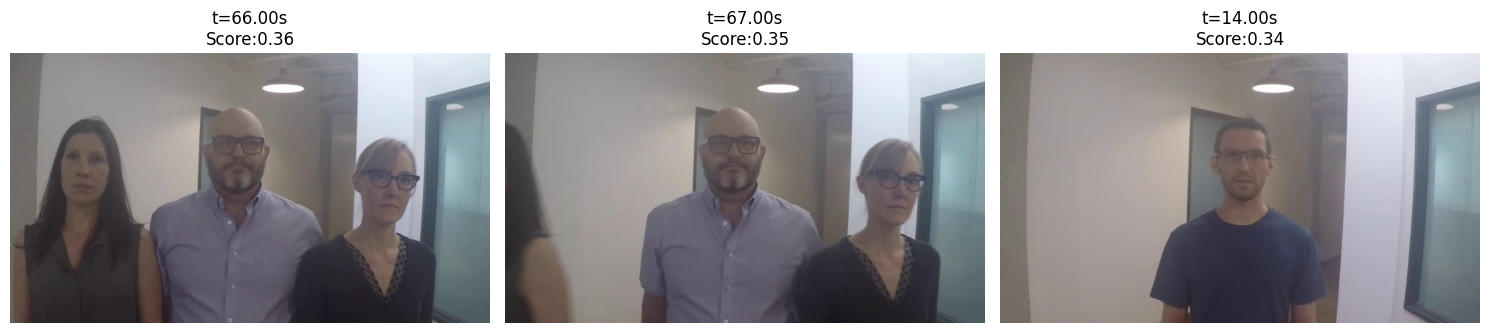

In [11]:
def show_retrieved_images(retrieved_results):
    n = len(retrieved_results)
    fig, axes = plt.subplots(1, n, figsize=(5*n, 5))
    if n == 1:
        axes = [axes]
    for ax, res in zip(axes, retrieved_results):
        img = cv2.imread(res["image_path"])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        ax.imshow(img)
        ax.set_title(f"t={res['timestamp']:.2f}s\nScore:{res['score']:.2f}")
        ax.axis('off')
    plt.tight_layout()
    plt.show()

show_retrieved_images(retrieved)

<h2 style="
text-align:center;
color:#203a43;
font-weight:bold;
font-size:28px;
letter-spacing:1px;
text-shadow: 2px 2px 6px rgba(32,58,67,0.35);
margin-top:20px;
">
RAG: Generate Answer using Retrieved Context</h2>

In [12]:
model_name = "google/flan-t5-small"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSeq2SeqLM.from_pretrained(model_name).cuda()  

def generate_answer(query, retrieved_contexts, max_context=3):
    context = "\n".join([f"- {r['description']}" for r in retrieved_contexts[:max_context]])

    prompt = f"""Based on the following observations from a surveillance video, answer the question briefly.

Observations:
{context}

Question: {query}

Answer:"""

    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=512).to("cuda")
    outputs = model.generate(**inputs, max_new_tokens=50, temperature=0.3)
    answer = tokenizer.decode(outputs[0], skip_special_tokens=True)
    return answer

answer = generate_answer(query, retrieved)
print(f"Query: {query}\n")
print(f"Generated Answer: {answer}")

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

...

Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Query: Are there any people walking?

Generated Answer: No


<h2 style="
text-align:center;
color:#203a43;
font-weight:bold;
font-size:34px;
letter-spacing:1px;
text-shadow: 2px 2px 6px rgba(32,58,67,0.35);
margin-top:20px;
">
Test another query.</h2>

In [13]:
query2 = "What objects are present at the beginning of the video?"
retrieved2 = retrieve_frames(query2, k=3)
answer2 = generate_answer(query2, retrieved2)
print(f"Query: {query2}\n")
print(f"Generated Answer: {answer2}")

Query: What objects are present at the beginning of the video?

Generated Answer: At 0.00 seconds: no objects detected.


<h2 style="
text-align:center;
color:#203a43;
font-weight:bold;
font-size:34px;
letter-spacing:1px;
text-shadow: 2px 2px 6px rgba(32,58,67,0.35);
margin-top:20px;
">
Evaluation</h2>

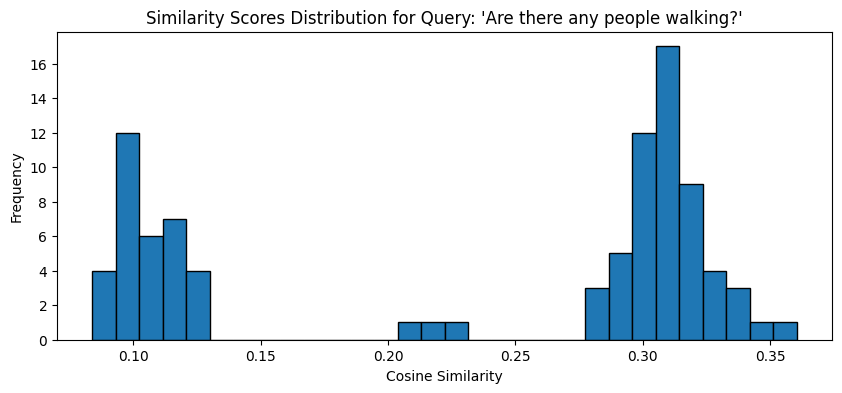

In [14]:
query_vec = embedder.encode([query], convert_to_numpy=True)
faiss.normalize_L2(query_vec)
all_scores = index.search(query_vec, index.ntotal)[0][0]

plt.figure(figsize=(10,4))
plt.hist(all_scores, bins=30, edgecolor='black')
plt.title(f"Similarity Scores Distribution for Query: '{query}'")
plt.xlabel("Cosine Similarity")
plt.ylabel("Frequency")
plt.show()

<h2 style="
text-align:center;
color:#203a43;
font-weight:bold;
font-size:30px;
letter-spacing:1px;
text-shadow: 2px 2px 6px rgba(32,58,67,0.35);
margin-top:20px;
">
More Query Examples and Analysis</h2>


QUERY: How many people are visible in the video?


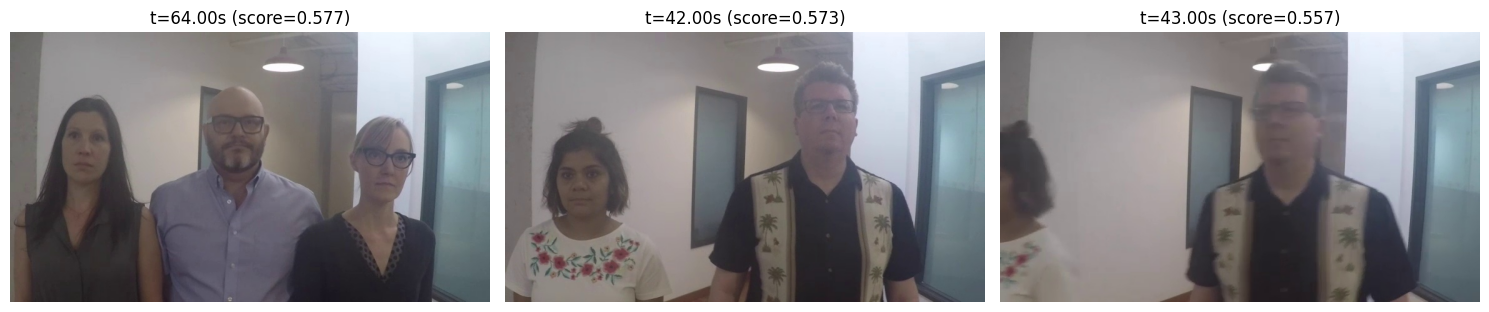


Generated Answer: 3 persons

QUERY: What objects are present around 2 seconds?


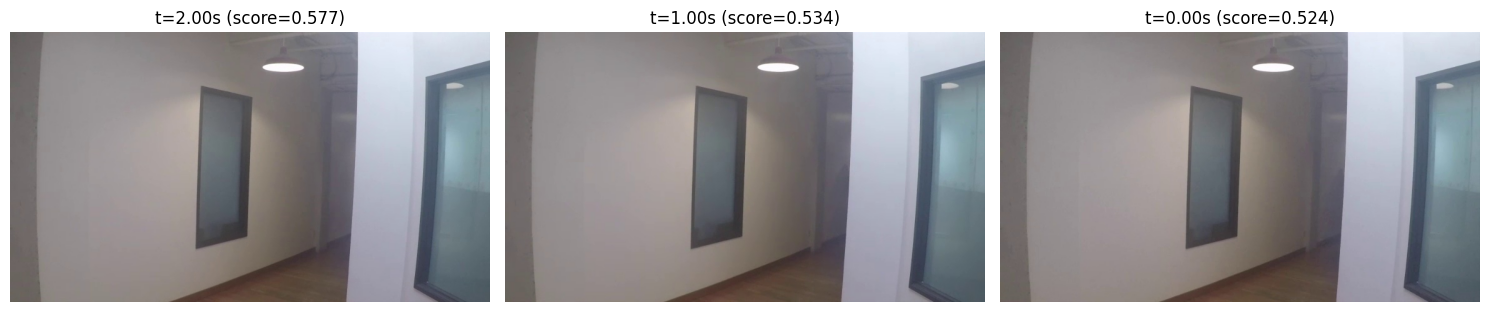


Generated Answer: At 1.00 seconds: no objects detected.

QUERY: Describe the scene at the very beginning.


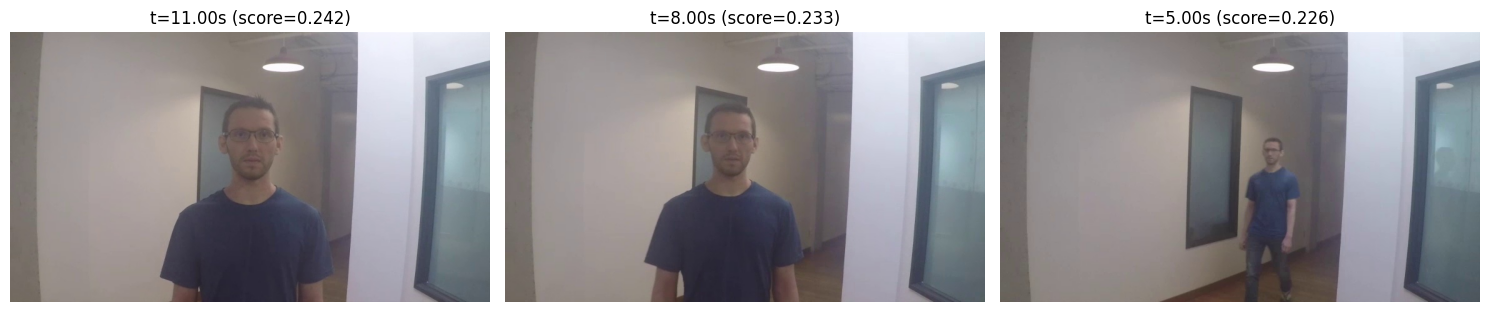


Generated Answer: At 5.00 seconds: 1 person

QUERY: Are there any instances of people running?


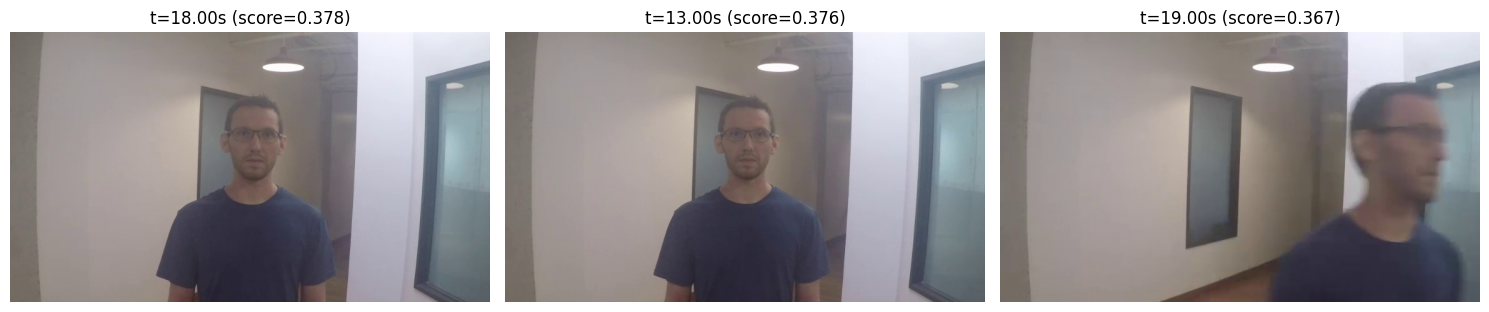


Generated Answer: At 19.00 seconds: 2 persons

QUERY: What is the most common object detected?


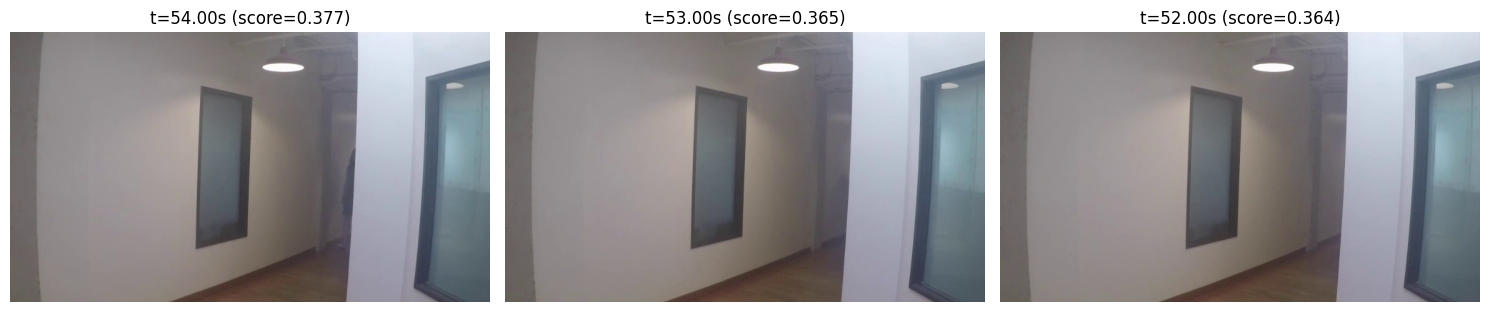


Generated Answer: At 54.00 seconds: no objects detected.


In [15]:
test_queries = [
    "How many people are visible in the video?",
    "What objects are present around 2 seconds?",
    "Describe the scene at the very beginning.",
    "Are there any instances of people running?",
    "What is the most common object detected?"
]

def show_images_grid(image_paths, titles, cols=3):
    rows = (len(image_paths) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 5*rows))
    if rows == 1:
        axes = axes.flatten()
    else:
        axes = axes.ravel()
    for i, (img_path, title) in enumerate(zip(image_paths, titles)):
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[i].imshow(img)
        axes[i].set_title(title)
        axes[i].axis('off')
    for j in range(i+1, len(axes)):
        axes[j].axis('off')
    plt.tight_layout()
    plt.show()

results_summary = []

for q in test_queries:
    print(f"\n{'='*60}")
    print(f"QUERY: {q}")
    print('='*60)

    retrieved = retrieve_frames(q, k=3)

    if not retrieved:
        print("No relevant frames found.")
        continue

    img_paths = [r["image_path"] for r in retrieved]
    titles = [f"t={r['timestamp']:.2f}s (score={r['score']:.3f})" for r in retrieved]
    show_images_grid(img_paths, titles, cols=3)

    answer = generate_answer(q, retrieved)
    print(f"\nGenerated Answer: {answer}")

    results_summary.append({
        "query": q,
        "retrieved_timestamps": [r["timestamp"] for r in retrieved],
        "answer": answer
    })